In [2]:
"""
Andreev Bound State (ABS) Solver for Josephson Junctions
=========================================================
Computes and plots ABS spectra for two junction types:
  - MATBG-JJ  : Magic-Angle Twisted Bilayer Graphene  (E_A = 1.2 meV,  E_T = 0.065 meV)
  - AABLG-JJ  : AA-stacked Bilayer Graphene           (E_A → ∞,         E_T = 5.75  meV)

Physics
-------
ABS energies are solutions of the self-consistency equation (Eq. 2 of main text):

    cos[2(β - (ε_η - η Δ_v)/E_T)] = cos(φ + (ε_η - η Δ_v)/(η E_A))

where β = arccos(ε_η / Δ_s),  η = ±1 is the valley index,
φ is the superconducting phase difference, and Δ_v the valley-polarization potential.

MATBG supports up to 4 ABS per valley (n_max = 4).
AABLG  supports up to 2 ABS per valley (n_max = 2), since E_A → ∞ removes the
anomalous φ₀-junction term.

Usage
-----
    python abs_solver.py

Dependencies: numpy, matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter


# ---------------------------------------------------------------------------
# Core solver
# ---------------------------------------------------------------------------

def _find_roots_by_sign_change(g, beta_arr):
    """
    Locate roots of g(β) = 0 by linear interpolation across sign changes.

    Parameters
    ----------
    g        : (N,) array   Function values on beta_arr
    beta_arr : (N,) array   Uniformly spaced β grid

    Returns
    -------
    roots : list of float   Approximate root locations
    """
    roots = []
    n_vals = np.unique(np.floor(g / (2 * np.pi)).astype(int))
    for n in n_vals:
        h = g - 2 * np.pi * n
        for i in range(len(h) - 1):
            if h[i] * h[i + 1] < 0:
                b0, b1 = beta_arr[i], beta_arr[i + 1]
                roots.append(b0 - h[i] * (b1 - b0) / (h[i + 1] - h[i]))
                break
    return roots


def _deduplicate(roots, tol=1e-8):
    """Remove roots closer than tol to each other."""
    if not roots:
        return roots
    roots = sorted(roots)
    clean = [roots[0]]
    for r in roots[1:]:
        if abs(r - clean[-1]) > tol:
            clean.append(r)
    return clean


def _fix_root_count(roots, Ds, target):
    """
    Adjust the root list to exactly `target` entries by
    removing roots near ±Δ_s (gap edge) or adding ±Δ_s placeholders.

    Parameters
    ----------
    roots  : list of float   Current ABS energies
    Ds     : float           Superconducting gap (meV)
    target : int             Desired number of roots (2 for AABLG, 4 for MATBG)

    Returns
    -------
    roots : list of float (length == target)
    """
    roots = sorted(roots)

    while len(roots) > target:
        dist = [min(abs(e - Ds), abs(e + Ds)) for e in roots]
        roots.pop(int(np.argmin(dist)))

    while len(roots) < target:
        pos_count = sum(1 for e in roots if e > 0)
        neg_count = sum(1 for e in roots if e < 0)
        roots.append(Ds if pos_count <= neg_count else -Ds)
        roots = sorted(roots)

    return roots


def compute_abs(EA, ET, Ds, Dv, n_max=4, N_beta=5000, N_phi=200):
    """
    Compute ABS energies as a function of superconducting phase φ ∈ [0, 2π].

    Parameters
    ----------
    EA     : float   Trigonal-warping energy scale E_A (meV); use a large number for AABLG
    ET     : float   Thouless energy E_T (meV)
    Ds     : float   Superconducting gap Δ_s (meV)
    Dv     : float   Valley-polarization potential Δ_v (meV)
    n_max  : int     Maximum ABS per valley (4 for MATBG, 2 for AABLG)
    N_beta : int     β grid resolution for root finding
    N_phi  : int     Number of φ points

    Returns
    -------
    phi_arr : (N_phi,)              Phase values [0, 2π]
    abs_p   : list of (n_max,)      ABS energies at each φ for η = +1
    abs_m   : list of (n_max,)      ABS energies at each φ for η = -1
    """
    phi_arr  = np.linspace(0, 2 * np.pi, N_phi)
    beta_arr = np.linspace(1e-10, np.pi - 1e-10, N_beta)

    abs_p, abs_m = [], []

    for phi in phi_arr:
        for eta, store in [(+1, abs_p), (-1, abs_m)]:

            ed_arr = Ds * np.cos(beta_arr) - eta * Dv

            # ABS condition: two families (g1, g2) from cos(...) = cos(...)
            g1 = 2 * beta_arr - 2 * ed_arr / ET - phi - ed_arr / (eta * EA)
            g2 = 2 * beta_arr - 2 * ed_arr / ET + phi + ed_arr / (eta * EA)

            raw_roots = []
            for g in [g1, g2]:
                for b_root in _find_roots_by_sign_change(g, beta_arr):
                    et = Ds * np.cos(b_root)
                    if not any(abs(et - e) < 1e-7 for e in raw_roots):
                        raw_roots.append(et)

            raw_roots = _deduplicate(raw_roots, tol=1e-8)
            raw_roots = _fix_root_count(raw_roots, Ds, target=n_max)
            store.append(np.array(sorted(raw_roots)))

    return phi_arr, abs_p, abs_m


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_abs(phi_arr, abs_p, abs_m, Ds, Dv, N_phi, title_tag="", save=False, filename_tag=""):
    """
    Plot ABS spectrum (η = ±1) as a function of φ.

    Parameters
    ----------
    phi_arr    : (N_phi,)           Phase array
    abs_p      : list of arrays     ABS energies for η = +1
    abs_m      : list of arrays     ABS energies for η = -1
    Ds         : float              Superconducting gap (for gap lines)
    Dv         : float              Valley polarization (for annotation)
    N_phi      : int                Number of φ points
    title_tag  : str                Label for the plot title
    save       : bool               Whether to save data files
    filename_tag : str              Prefix for saved files
    """
    phi_plot_p = np.concatenate([[phi_arr[i]] * len(abs_p[i]) for i in range(N_phi)])
    et_plot_p  = np.concatenate([abs_p[i] for i in range(N_phi)])
    phi_plot_m = np.concatenate([[phi_arr[i]] * len(abs_m[i]) for i in range(N_phi)])
    et_plot_m  = np.concatenate([abs_m[i] for i in range(N_phi)])

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(phi_plot_p, et_plot_p, color='red',  s=7, label=r'$\eta = +1$')
    ax.scatter(phi_plot_m, et_plot_m, color='blue', s=1, label=r'$\eta = -1$')

    ax.axhline( Ds, color='black', lw=2, ls='--', alpha=0.9, label=r'$\pm\Delta_s$')
    ax.axhline(-Ds, color='black', lw=2, ls='--', alpha=0.9)

    ax.set_xlabel(r'$\phi$',              fontsize=40)
    ax.set_ylabel(r'$\epsilon_\eta$ (meV)', fontsize=40)

    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
    ax.tick_params(axis='both', labelsize=30)
    ax.grid(True, lw=0.3)
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    ax.legend(markerscale=5, fontsize=25)

    plt.tight_layout()
    plt.show()

    if save and filename_tag:
        data_p = np.column_stack([phi_arr, np.array([abs_p[i] for i in range(N_phi)])])
        data_m = np.column_stack([phi_arr, np.array([abs_m[i] for i in range(N_phi)])])
        np.savetxt(f"{filename_tag}_taup_Dv{Dv:.4f}.dat", data_p,
                   header="phi  e1(meV)  e2(meV)  [e3  e4  if MATBG]", comments="# ")
        np.savetxt(f"{filename_tag}_taum_Dv{Dv:.4f}.dat", data_m,
                   header="phi  e1(meV)  e2(meV)  [e3  e4  if MATBG]", comments="# ")


# ---------------------------------------------------------------------------
# System-specific wrappers
# ---------------------------------------------------------------------------

def compute_abs_MATBG(Dv, Ds=0.1, N_beta=5000, N_phi=200):
    """
    Compute ABS for MATBG-JJ.

    Uses E_A = 1.2 meV (trigonal warping scale) and E_T = 0.065 meV (Thouless energy).
    Supports up to 4 ABS per valley (n_max = 4).

    Parameters
    ----------
    Dv     : float   Valley-polarization potential Δ_v (meV)
    Ds     : float   Superconducting gap Δ_s (meV)  [default: 0.1]
    N_beta : int     β-grid resolution              [default: 5000]
    N_phi  : int     Number of φ points             [default: 200]

    Returns
    -------
    phi_arr, abs_p, abs_m  (see compute_abs)
    """
    EA = 1.2    # meV — trigonal-warping energy scale for MATBG
    ET = 0.065  # meV — Thouless energy for MATBG
    return compute_abs(EA, ET, Ds, Dv, n_max=4, N_beta=N_beta, N_phi=N_phi)


def compute_abs_AABLG(Dv, Ds=0.1, N_beta=5000, N_phi=200):
    """
    Compute ABS for AABLG-JJ.

    Uses E_A → ∞ (no trigonal warping) and E_T = 5.75 meV (Thouless energy).
    Supports up to 2 ABS per valley (n_max = 2).

    Parameters
    ----------
    Dv     : float   Valley-polarization potential Δ_v (meV)
    Ds     : float   Superconducting gap Δ_s (meV)  [default: 0.1]
    N_beta : int     β-grid resolution              [default: 5000]
    N_phi  : int     Number of φ points             [default: 200]

    Returns
    -------
    phi_arr, abs_p, abs_m  (see compute_abs)
    """
    EA = 1e12   # meV — effectively infinite (no trigonal warping in AABLG)
    ET = 5.75   # meV — Thouless energy for AABLG
    return compute_abs(EA, ET, Ds, Dv, n_max=2, N_beta=N_beta, N_phi=N_phi)






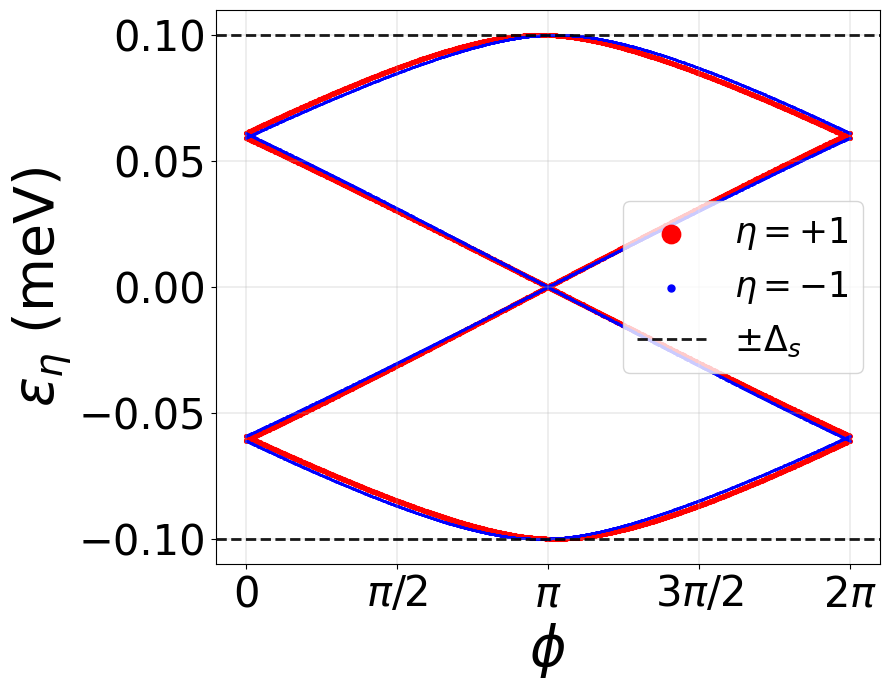

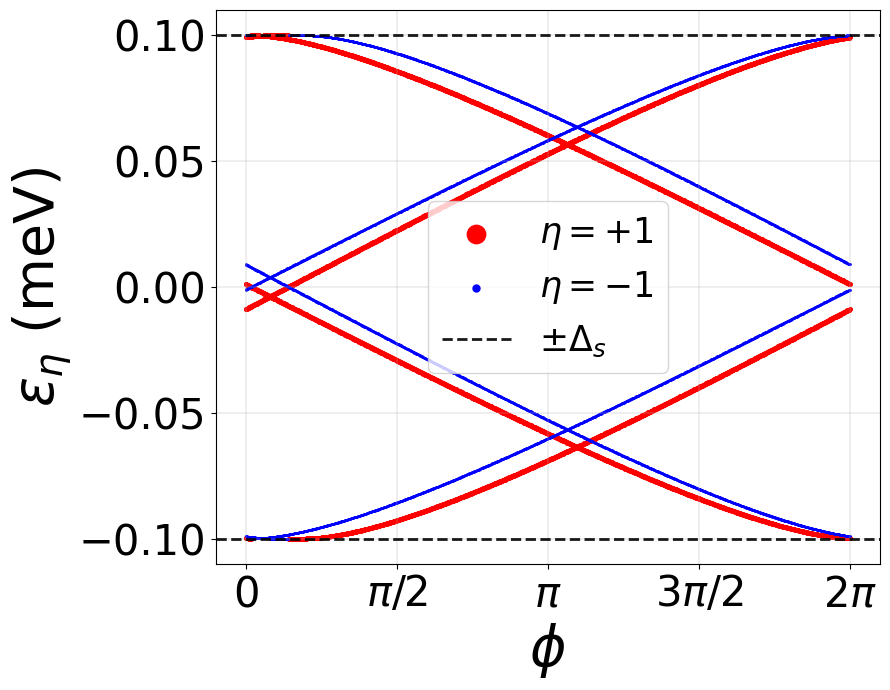

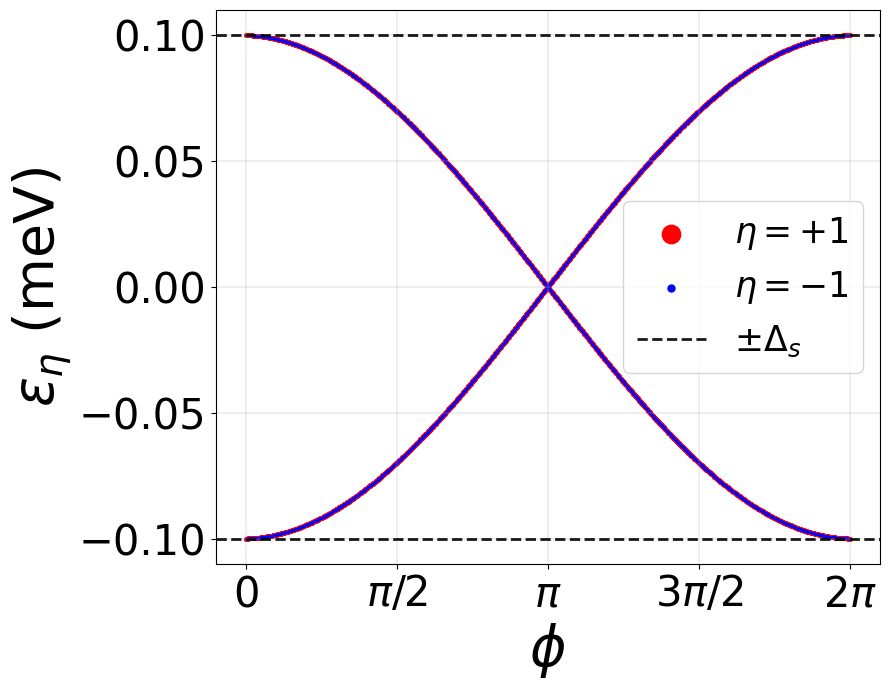

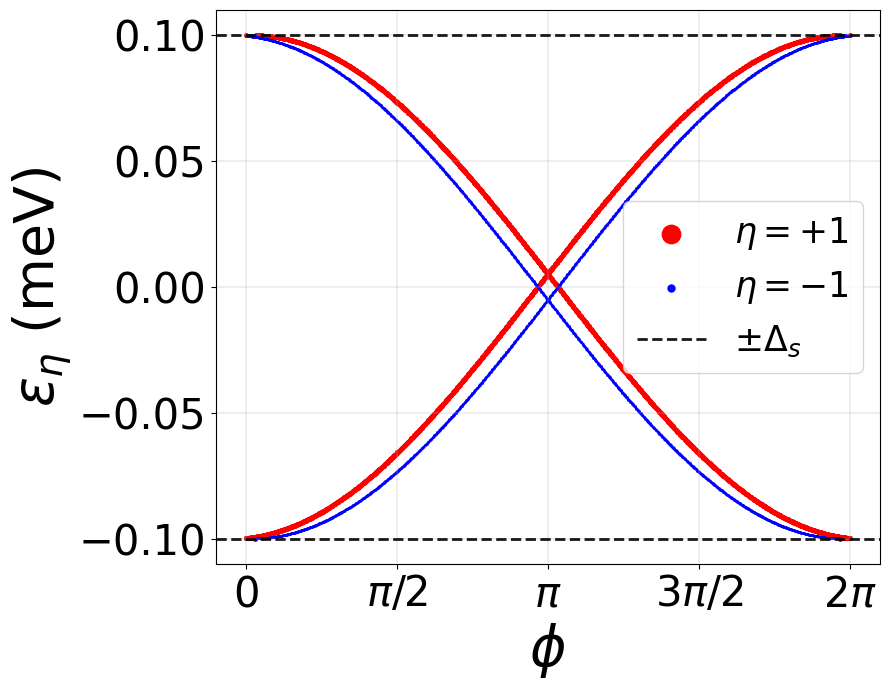

In [4]:

Ds     = 0.1    # meV — superconducting gap
N_beta = 1000
N_phi  = 1000

# ------------------------------------------------------------------
# MATBG : Δ_v = 0 and Δ_v = 0.3 meV
# ------------------------------------------------------------------
for Dv in [0.0, 0.3]:
    phi_arr, abs_p, abs_m = compute_abs_MATBG(Dv=Dv, Ds=Ds,N_beta=N_beta, N_phi=N_phi)
    plot_abs(phi_arr, abs_p, abs_m, Ds=Ds, Dv=Dv, N_phi=N_phi, title_tag="MATBG", save=False, filename_tag="ABS_MATBG")

# ------------------------------------------------------------------
# AABLG : Δ_v = 0 and Δ_v = 0.3 meV
 # ------------------------------------------------------------------
for Dv in [0.0, 0.3]:
    phi_arr, abs_p, abs_m = compute_abs_AABLG(Dv=Dv, Ds=Ds,N_beta=N_beta, N_phi=N_phi)
    plot_abs(phi_arr, abs_p, abs_m, Ds=Ds, Dv=Dv, N_phi=N_phi, title_tag="AABLG", save=False, filename_tag="ABS_AABLG")

In [10]:
# ---------------------------------------------------------------------------
# Current-Phase Relation (CPR)
# ---------------------------------------------------------------------------

def compute_cpr(phi_arr, abs_p, abs_m, T=0.05, kB=0.08617):
    """
    Compute the free energy F(φ) and supercurrent I(φ) from ABS spectra.

    The free energy at temperature T is:

        F(φ) = -k_B T  Σ_{n,η}  ln[1 + exp(-ε_{n,η} / k_B T)]

    At T → 0 this reduces to the sum of negative ABS energies.
    The supercurrent follows from:

        I(φ) = (2e/ħ) dF/dφ  [converted to nA via prefactor 468.782]

    The numerical derivative uses a central-difference scheme.

    Parameters
    ----------
    phi_arr : (N_phi,) array    Phase values returned by compute_abs
    abs_p   : list of arrays    ABS energies for η = +1  (from compute_abs)
    abs_m   : list of arrays    ABS energies for η = -1  (from compute_abs)
    T       : float             Temperature (K)          [default: 0.05]
    kB      : float             Boltzmann constant (meV/K) [default: 0.08617]

    Returns
    -------
    phi_arr : (N_phi,) array    Phase values (same as input)
    F_arr   : (N_phi,) array    Free energy F(φ) (meV)
    I_arr   : (N_phi,) array    Supercurrent I(φ) (nA)
    """
    N_phi = len(phi_arr)
    dphi  = phi_arr[1] - phi_arr[0]

    F_arr = np.empty(N_phi)
    for i in range(N_phi):
        all_e = np.concatenate([abs_p[i], abs_m[i]])
        all_e = all_e[np.isfinite(all_e)]
        if T < 1e-6:
            F_arr[i] = np.sum(all_e[all_e < 0])
        else:
            F_arr[i] = -kB * T * np.sum(np.log(1.0 + np.exp(-all_e / (kB * T))))

    # Central-difference derivative; edge points use the periodic roll
    I_arr = 468.782 * (np.roll(F_arr, -1) - np.roll(F_arr, 1)) / (2.0 * dphi)

    return phi_arr, F_arr, I_arr


def plot_cpr_multi(results, title_tag=""):
    """
    Plot CPR curves for multiple Δ_v values on a single axes.

    Each entry in `results` is the direct output of compute_cpr_MATBG /
    compute_cpr_AABLG, bundled with the Δ_v label used to produce it.

    A qualitative colormap (tab10) is used so curves are always visually
    distinct regardless of how many Δ_v values are supplied.

    Parameters
    ----------
    results   : list of (phi_arr, F_arr, I_arr, Dv)
                  phi_arr : (N_phi,) array   Phase values [0, 2π]
                  F_arr   : (N_phi,) array   Free energy (meV)  [unused in plot]
                  I_arr   : (N_phi,) array   Supercurrent (nA)
                  Dv      : float            Valley-polarization label (meV)
    title_tag : str   System label shown in the figure title (e.g. "MATBG")
    """
    _base_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    colors = [_base_colors[i % len(_base_colors)] for i in range(len(results))]

    fig, ax = plt.subplots(figsize=(9, 7))

    for (phi_arr, F_arr, I_arr, Dv), color in zip(results, colors):
        # Skip roll-artifact edge points; thin dense grids by factor 2
        ax.scatter(phi_arr[2:-2:2], I_arr[2:-2:2],
                   color=color, s=10,
                   label=rf'$\Delta_v = {Dv}$ meV', zorder=5)

    ax.axhline(0, color='gray', lw=0.5, ls=':', alpha=0.7)
    ax.set_xlabel(r'$\phi$',    fontsize=40)
    ax.set_ylabel(r'$I\ (nA)$', fontsize=40)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
    ax.tick_params(axis='both', labelsize=35)
    ax.grid(True, lw=0.3, alpha=0.7)
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
    ax.legend(markerscale=5, fontsize=20, loc='best')

    if title_tag:
        ax.set_title(title_tag, fontsize=28)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# System-specific CPR wrappers
# ---------------------------------------------------------------------------

def compute_cpr_MATBG(Dv, Ds=0.1, T=0.02, N_beta=5000, N_phi=1000):
    """
    Compute CPR for MATBG-JJ.

    Uses E_A = 1.2 meV (trigonal warping) and E_T = 0.065 meV (Thouless energy).
    ABS spectrum is computed with n_max = 4 modes per valley.

    Parameters
    ----------
    Dv     : float   Valley-polarization potential Δ_v (meV)
    Ds     : float   Superconducting gap Δ_s (meV)      [default: 0.1]
    T      : float   Temperature (K)                    [default: 0.02]
    N_beta : int     β-grid resolution                  [default: 5000]
    N_phi  : int     Number of φ points                 [default: 1000]

    Returns
    -------
    phi_arr : (N_phi,) array   Phase values [0, 2π]
    F_arr   : (N_phi,) array   Free energy F(φ) (meV)
    I_arr   : (N_phi,) array   Supercurrent I(φ) (nA)
    """
    phi_arr, abs_p, abs_m = compute_abs_MATBG(Dv=Dv, Ds=Ds, N_beta=N_beta, N_phi=N_phi)
    return compute_cpr(phi_arr, abs_p, abs_m, T=T)


def compute_cpr_AABLG(Dv, Ds=0.1, T=0.02, N_beta=5000, N_phi=1000):
    """
    Compute CPR for AABLG-JJ.

    Uses E_A → ∞ (no trigonal warping) and E_T = 5.75 meV (Thouless energy).
    ABS spectrum is computed with n_max = 2 modes per valley.

    Parameters
    ----------
    Dv     : float   Valley-polarization potential Δ_v (meV)
    Ds     : float   Superconducting gap Δ_s (meV)      [default: 0.1]
    T      : float   Temperature (K)                    [default: 0.02]
    N_beta : int     β-grid resolution                  [default: 5000]
    N_phi  : int     Number of φ points                 [default: 1000]

    Returns
    -------
    phi_arr : (N_phi,) array   Phase values [0, 2π]
    F_arr   : (N_phi,) array   Free energy F(φ) (meV)
    I_arr   : (N_phi,) array   Supercurrent I(φ) (nA)
    """
    phi_arr, abs_p, abs_m = compute_abs_AABLG(Dv=Dv, Ds=Ds, N_beta=N_beta, N_phi=N_phi)
    return compute_cpr(phi_arr, abs_p, abs_m, T=T)

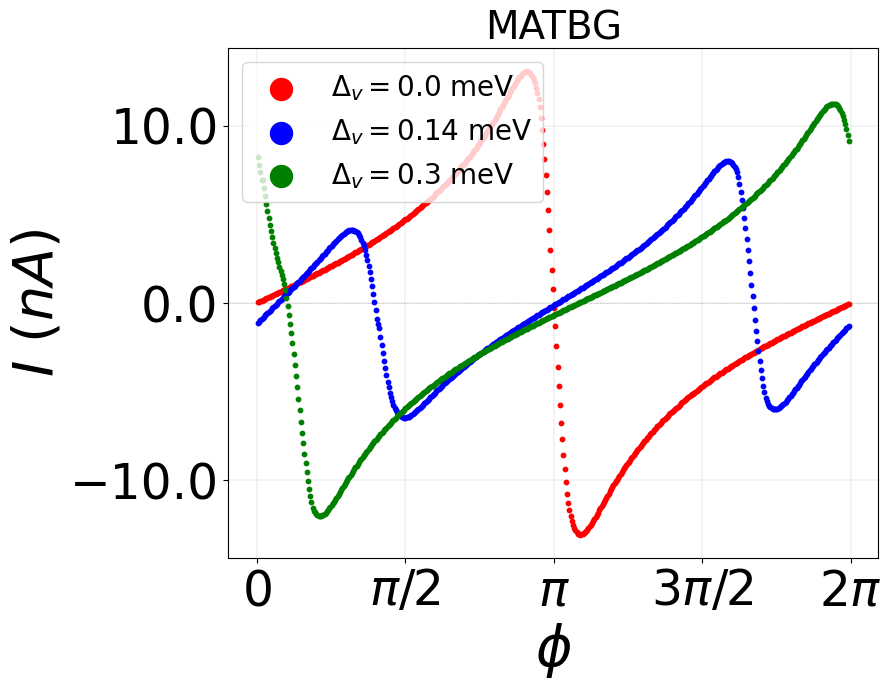

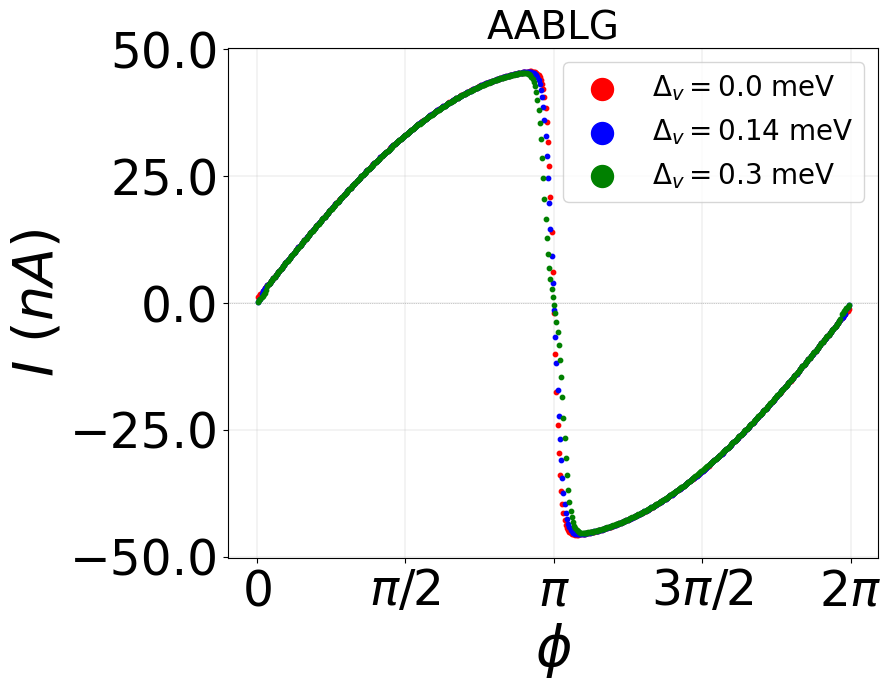

In [11]:

Ds     = 0.1   # meV — superconducting gap
T      = 0.02  # K   — temperature
N_beta = 1000
N_phi  = 1000

Dv_list = [0.0, 0.14,  0.3]   # ← edit this freely

# ------------------------------------------------------------------
# MATBG : one plot, all Δ_v values
# ------------------------------------------------------------------
matbg_results = []
for Dv in Dv_list:
    phi_arr, F_arr, I_arr = compute_cpr_MATBG(Dv=Dv, Ds=Ds, T=T,N_beta=N_beta, N_phi=N_phi)
    matbg_results.append((phi_arr, F_arr, I_arr, Dv))

plot_cpr_multi(matbg_results, title_tag="MATBG")


aablg_results = []
for Dv in Dv_list:
    phi_arr, F_arr, I_arr = compute_cpr_AABLG(Dv=Dv, Ds=Ds, T=T, N_beta=N_beta, N_phi=N_phi)
    aablg_results.append((phi_arr, F_arr, I_arr, Dv))

plot_cpr_multi(aablg_results, title_tag="AABLG")

In [28]:
from scipy.optimize import brentq
# ---------------------------------------------------------------------------
# ABS spectrum vs Δ_v  (at fixed φ)
# ---------------------------------------------------------------------------

def _find_roots_brentq(EA, ET, Ds, Dv, phi, tau, n_scan=8000):
    """
    Find ABS energies for a single (Δ_v, φ, η=tau) using Brent's method.

    The ABS condition is:

        cos(2β - 2ξ/E_T + φ) = cos(ξ / (η E_A))

    where ξ = ε_η - η Δ_v  and  ε_η = Δ_s cos(β).

    Sign changes of the residual are bracketed on a dense β grid and each
    bracket is refined with brentq. The four roots closest to zero are kept
    (gap-edge padding with +Δ_s if fewer than four are found).

    Parameters
    ----------
    EA     : float   Trigonal-warping energy scale E_A (meV)
    ET     : float   Thouless energy E_T (meV)
    Ds     : float   Superconducting gap Δ_s (meV)
    Dv     : float   Valley-polarization potential Δ_v (meV)
    phi    : float   Superconducting phase difference φ (rad)
    tau    : int     Valley index η = ±1
    n_scan : int     β-grid resolution for bracket search  [default: 8000]

    Returns
    -------
    roots : (4,) array   ABS energies sorted by value (meV)
    """
    def _residual(beta):
        et  = Ds * np.cos(beta)
        xi  = et - tau * Dv
        return np.cos(2 * beta - 2 * xi / ET + phi) - np.cos(xi / (tau * EA))

    beta_arr = np.linspace(1e-10, np.pi - 1e-10, n_scan)
    f_arr    = _residual(beta_arr)

    roots_et = []
    for i in range(len(beta_arr) - 1):
        if np.isnan(f_arr[i]) or np.isnan(f_arr[i + 1]):
            continue
        if f_arr[i] * f_arr[i + 1] < 0:
            b_root = brentq(_residual, beta_arr[i], beta_arr[i + 1])
            roots_et.append(Ds * np.cos(b_root))

    # Keep 4 roots closest to zero; pad with +Δ_s if fewer found
    roots_et = sorted(roots_et, key=abs)[:4]
    while len(roots_et) < 4:
        roots_et.append(Ds)

    return np.array(sorted(roots_et))


def compute_abs_vs_Dv(EA, ET, Ds, phi, N_Dv=1000, n_scan=8000):
    """
    Compute ABS energies as a function of valley polarization Δ_v at fixed φ.

    For each Δ_v the η = +1 roots are found via Brent's method; the η = -1
    roots follow by particle-hole symmetry:  ε_{-1} = -ε_{+1}  (reversed).

    Parameters
    ----------
    EA     : float   Trigonal-warping energy scale E_A (meV)
    ET     : float   Thouless energy E_T (meV)
    Ds     : float   Superconducting gap Δ_s (meV)
    phi    : float   Superconducting phase difference φ (rad)
    N_Dv   : int     Number of Δ_v points               [default: 1000]
    n_scan : int     β-grid resolution for root finding  [default: 8000]

    Returns
    -------
    Dv_arr     : (N_Dv,)    Valley-polarization values (meV)
    energy_arr : (N_Dv, 8)  ABS energies (meV); columns 0-3 → η=+1, 4-7 → η=-1
    """
    Dv_arr     = np.linspace(0, 0.4, N_Dv)
    energy_arr = np.empty((N_Dv, 8))

    for k, Dv in enumerate(Dv_arr):
        roots_p = _find_roots_brentq(EA, ET, Ds, Dv, phi, tau=+1, n_scan=n_scan)
        roots_m = -roots_p[::-1]                 # particle-hole symmetry
        energy_arr[k] = np.concatenate([roots_p, roots_m])

    return Dv_arr, energy_arr


def plot_abs_vs_Dv(Dv_arr, energy_arr, Ds, phi, title_tag=""):
    """
    Plot ABS energies vs Δ_v for η = ±1.

    Parameters
    ----------
    Dv_arr     : (N_Dv,)    Valley-polarization values (meV)
    energy_arr : (N_Dv, 8)  ABS energies from compute_abs_vs_Dv
    Ds         : float      Superconducting gap Δ_s (meV)  [for gap lines]
    phi        : float      Phase φ (rad)                  [for annotation]
    title_tag  : str        System label for the plot title (e.g. "MATBG")
    """
    # Unpack η = +1 (cols 0-3) and η = -1 (cols 4-7)
    Dv_rep_p = np.repeat(Dv_arr, 4)
    Dv_rep_m = np.repeat(Dv_arr, 4)
    et_p     = energy_arr[:, :4].ravel()
    et_m     = energy_arr[:, 4:].ravel()

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(Dv_rep_p, et_p, s=7, color='red',  label=r'$\eta = +1$')
    ax.scatter(Dv_rep_m, et_m, s=1, color='blue', label=r'$\eta = -1$')

    ax.axhline( Ds, color='black', lw=2, ls='--', alpha=0.9, label=r'$\pm\Delta_s$')
    ax.axhline(-Ds, color='black', lw=2, ls='--', alpha=0.9)

    ax.set_xlabel(r'$\Delta_v$ (meV)',          fontsize=40)
    ax.set_ylabel(r'$\epsilon_\eta$ (meV)',      fontsize=40)
    ax.tick_params(axis='both', labelsize=30)
    ax.set_ylim(-Ds * 1.15, Ds * 1.15)
    ax.legend(markerscale=8, fontsize=25)

    if title_tag:
        ax.set_title(title_tag, fontsize=28)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# System-specific wrapper
# ---------------------------------------------------------------------------

def compute_abs_vs_Dv_MATBG(phi, Ds=0.1, N_Dv=1000, n_scan=8000):
    """
    Compute ABS vs Δ_v at fixed φ for MATBG-JJ.

    Uses E_A = 1.2 meV (trigonal warping) and E_T = 0.065 meV (Thouless energy).

    Parameters
    ----------
    phi    : float   Superconducting phase difference φ (rad)
    Ds     : float   Superconducting gap Δ_s (meV)       [default: 0.1]
    N_Dv   : int     Number of Δ_v points                [default: 1000]
    n_scan : int     β-grid resolution for root finding   [default: 8000]

    Returns
    -------
    Dv_arr     : (N_Dv,)    Valley-polarization values (meV)
    energy_arr : (N_Dv, 8)  ABS energies (meV); columns 0-3 → η=+1, 4-7 → η=-1
    """
    EA = 1.2    # meV — trigonal-warping energy scale for MATBG
    ET = 0.065  # meV — Thouless energy for MATBG
    return compute_abs_vs_Dv(EA, ET, Ds, phi, N_Dv=N_Dv, n_scan=n_scan)

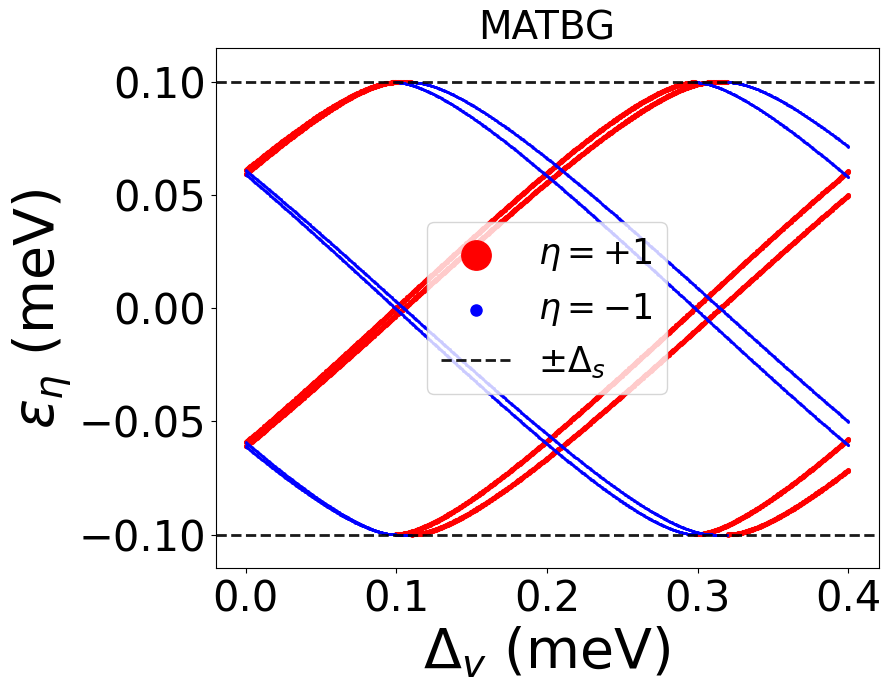

In [29]:
Ds     = 0.1   # meV — superconducting gap
phi    = 0.0   # rad — fixed phase
N_Dv   = 1000
n_scan = 8000

# ------------------------------------------------------------------
# MATBG : ABS spectrum vs Δ_v at fixed φ
# ------------------------------------------------------------------
Dv_arr, energy_arr = compute_abs_vs_Dv_MATBG(phi=phi, Ds=Ds,N_Dv=N_Dv, n_scan=n_scan)
plot_abs_vs_Dv(Dv_arr, energy_arr, Ds=Ds, phi=phi, title_tag="MATBG")

In [22]:
# ---------------------------------------------------------------------------
# Anomalous current  I_ano(φ=0) vs Δ_v
# ---------------------------------------------------------------------------

def compute_anomalous_current( Ds, Dv_arr, EA=1.2, ET=0.065, T=0.05, N_beta=5000, kB=0.08617,
                               dphi=1e-6):
    """
    Compute the anomalous supercurrent I(φ=0) as a function of valley
    polarization Δ_v, using a two-point central-difference derivative:

        I(φ=0) = (2e/ħ) · [F(+δφ) - F(-δφ)] / (2 δφ)   [converted to nA]

    F(φ) is the ABS free energy (see compute_cpr). A tiny δφ = 1e-6 rad is
    used so the derivative is effectively exact while avoiding finite-size
    artefacts from a coarse φ grid.

    Internal root-finding reuses _find_roots_by_sign_change, _deduplicate,
    and _fix_root_count from the core solver.

    Parameters
    ----------
    EA     : float            Trigonal-warping energy scale E_A (meV)
    ET     : float            Thouless energy E_T (meV)
    Ds     : float            Superconducting gap Δ_s (meV)
    Dv_arr : (N_Dv,) array   Valley-polarization values to sweep (meV)
    T      : float            Temperature (K)              [default: 0.05]
    N_beta : int              β-grid resolution            [default: 5000]
    kB     : float            Boltzmann constant (meV/K)   [default: 0.08617]
    dphi   : float            Half-step δφ for derivative  [default: 1e-6]

    Returns
    -------
    Dv_arr : (N_Dv,) array   Valley-polarization values (meV)  [same as input]
    F0_arr : (N_Dv,) array   Free energy at φ=0 (meV)
    I_arr  : (N_Dv,) array   Anomalous current I(φ=0) (nA)
    """
    beta_arr = np.linspace(1e-10, np.pi - 1e-10, N_beta)

    def _free_energy(phi, Dv):
        """Evaluate F(φ) for a single (φ, Δ_v) pair."""
        all_e = []
        for eta in [+1, -1]:
            ed_arr   = Ds * np.cos(beta_arr) - eta * Dv
            g1 = 2 * beta_arr - 2 * ed_arr / ET - phi - ed_arr / (eta * EA)
            g2 = 2 * beta_arr - 2 * ed_arr / ET + phi + ed_arr / (eta * EA)

            et_roots = []
            for g in [g1, g2]:
                for b_root in _find_roots_by_sign_change(g, beta_arr):
                    et = Ds * np.cos(b_root)
                    if not any(abs(et - e) < 1e-7 for e in et_roots):
                        et_roots.append(et)

            et_roots = _deduplicate(et_roots, tol=1e-8)
            et_roots = _fix_root_count(et_roots, Ds, target=4)
            all_e.extend(et_roots)

        all_e = np.array(all_e)
        if T < 1e-6:
            return np.sum(all_e[all_e < 0])
        return -kB * T * np.sum(np.log(1.0 + np.exp(-all_e / (kB * T))))

    F0_arr = np.empty(len(Dv_arr))
    I_arr  = np.empty(len(Dv_arr))

    for k, Dv in enumerate(Dv_arr):
        F_m     = _free_energy(-dphi, Dv)
        F_0     = _free_energy( 0.0,  Dv)
        F_p     = _free_energy(+dphi, Dv)

        F0_arr[k] = F_0
        I_arr[k]  = 468.782 * (F_p - F_m) / (2.0 * dphi)

        print(f"Dv = {Dv:.4f} meV   F(phi=0) = {F_0:.6f} meV"
              f"   I_ano(phi=0) = {I_arr[k]:.6f} nA")

    return Dv_arr, F0_arr, I_arr


def plot_anomalous_current(Dv_arr, I_arr, title_tag="", color="black"):
    """
    Plot the anomalous supercurrent I(φ=0) as a function of Δ_v.

    Parameters
    ----------
    Dv_arr    : (N_Dv,) array   Valley-polarization values (meV)
    I_arr     : (N_Dv,) array   Anomalous current (nA)
    title_tag : str             System label for the plot title (e.g. "MATBG")
    color     : str             Scatter plot color             [default: "black"]
    """
    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(Dv_arr, I_arr, color=color, s=10)
    ax.axhline(0, color='gray', lw=2, ls='--', alpha=0.9)

    ax.set_xlabel(r'$\Delta_v$ (meV)',        fontsize=40)
    ax.set_ylabel(r'$I_{\rm ano}(\phi=0)$ (nA)', fontsize=40)
    ax.tick_params(axis='both', labelsize=30)
    ax.grid(True, lw=0.3, alpha=0.7)
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))

    if title_tag:
        ax.set_title(title_tag, fontsize=28)

    plt.tight_layout()
    plt.show()






Dv = 0.0000 meV   F(phi=0) = -0.240652 meV   I_ano(phi=0) = 0.000000 nA
Dv = 0.0002 meV   F(phi=0) = -0.240652 meV   I_ano(phi=0) = 0.000546 nA
Dv = 0.0004 meV   F(phi=0) = -0.240651 meV   I_ano(phi=0) = 0.001093 nA
Dv = 0.0006 meV   F(phi=0) = -0.240651 meV   I_ano(phi=0) = 0.012741 nA
Dv = 0.0008 meV   F(phi=0) = -0.240650 meV   I_ano(phi=0) = -0.008666 nA
Dv = 0.0010 meV   F(phi=0) = -0.240649 meV   I_ano(phi=0) = 0.003124 nA
Dv = 0.0012 meV   F(phi=0) = -0.240648 meV   I_ano(phi=0) = 0.003669 nA
Dv = 0.0014 meV   F(phi=0) = -0.240647 meV   I_ano(phi=0) = 0.004217 nA
Dv = 0.0016 meV   F(phi=0) = -0.240645 meV   I_ano(phi=0) = 0.004762 nA
Dv = 0.0018 meV   F(phi=0) = -0.240644 meV   I_ano(phi=0) = 0.005310 nA
Dv = 0.0020 meV   F(phi=0) = -0.240642 meV   I_ano(phi=0) = 0.016815 nA
Dv = 0.0022 meV   F(phi=0) = -0.240639 meV   I_ano(phi=0) = 0.006403 nA
Dv = 0.0024 meV   F(phi=0) = -0.240637 meV   I_ano(phi=0) = 0.017853 nA
Dv = 0.0026 meV   F(phi=0) = -0.240634 meV   I_ano(phi=0) = -0.

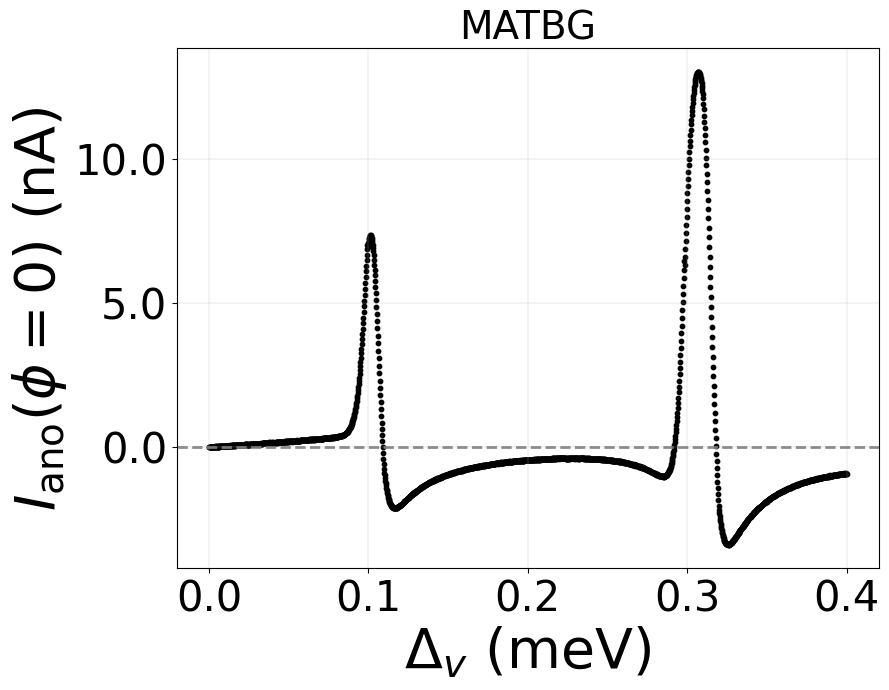

In [23]:

Ds     = 0.1                            # meV — superconducting gap
T      = 0.02                           # K   — temperature
N_beta = 1000
Dv_arr = np.linspace(0, 0.4, 2000)       # meV — Δ_v sweep

# ------------------------------------------------------------------
# MATBG : I_ano(φ=0) vs Δ_v
# ------------------------------------------------------------------
Dv_arr, F0_matbg, I_matbg = compute_anomalous_current(Ds=Ds,Dv_arr= Dv_arr,T=T, N_beta=N_beta)
plot_anomalous_current(Dv_arr, I_matbg, title_tag="MATBG")




In [30]:
# ---------------------------------------------------------------------------
# Diode efficiency η_DE vs Δ_v
# ---------------------------------------------------------------------------

def compute_diode_efficiency(EA, ET, Ds, Dv_arr, T=0.02, N_beta=5000, N_phi=400,
                              kB=0.08617):
    """
    Compute the superconducting diode efficiency η_DE as a function of Δ_v.

    The diode efficiency is defined as:

        η_DE = (|I_max| - |I_min|) / (|I_max| + |I_min|)

    where I_max and I_min are the maximum and minimum of the CPR I(φ) over
    φ ∈ [0, 2π].  A non-zero η_DE signals a φ₀-junction (broken inversion
    symmetry), with η_DE = ±1 being the ideal diode limit.

    The CPR is obtained from the ABS free energy via:

        I(φ) = (2e/ħ) dF/dφ   [converted to nA via prefactor 468.782]

    using numpy.gradient for the derivative over the full φ grid.

    Parameters
    ----------
    EA     : float            Trigonal-warping energy scale E_A (meV)
    ET     : float            Thouless energy E_T (meV)
    Ds     : float            Superconducting gap Δ_s (meV)
    Dv_arr : (N_Dv,) array   Valley-polarization values to sweep (meV)
    T      : float            Temperature (K)              [default: 0.02]
    N_beta : int              β-grid resolution            [default: 5000]
    N_phi  : int              Number of φ points           [default: 400]
    kB     : float            Boltzmann constant (meV/K)   [default: 0.08617]

    Returns
    -------
    Dv_arr  : (N_Dv,) array   Valley-polarization values (meV)  [same as input]
    eta_arr : (N_Dv,) array   Diode efficiency η_DE (dimensionless, ∈ [-1, 1])
    """
    Dv_arr  = np.asarray(Dv_arr)
    eta_arr = np.empty(len(Dv_arr))
    width   = len(str(len(Dv_arr)))

    for k, Dv in enumerate(Dv_arr):
        phi_arr, abs_p, abs_m = compute_abs(EA, ET, Ds, Dv,
                                            N_beta=N_beta, N_phi=N_phi)

        F_arr = np.empty(N_phi)
        for i in range(N_phi):
            all_e = np.concatenate([abs_p[i], abs_m[i]])
            all_e = all_e[np.isfinite(all_e)]
            if T < 1e-6:
                F_arr[i] = np.sum(all_e[all_e < 0])
            else:
                F_arr[i] = -kB * T * np.sum(np.log(1.0 + np.exp(-all_e / (kB * T))))

        I_arr = 468.782 * np.gradient(F_arr, phi_arr)
        I_max = np.max(I_arr)
        I_min = np.min(I_arr)
        denom = abs(I_max) + abs(I_min)

        eta_arr[k] = (abs(I_max) - abs(I_min)) / denom if denom > 0 else 0.0

        print(f"[{k+1:>{width}}/{len(Dv_arr)}]  "
              f"Dv = {Dv:.4f} meV   "
              f"I_max = {I_max:.4f} nA   I_min = {I_min:.4f} nA   "
              f"eta_DE = {eta_arr[k]:.4f}")

    return Dv_arr, eta_arr


def plot_diode_efficiency(Dv_arr, eta_arr, title_tag="", color="black"):
    """
    Plot diode efficiency η_DE as a function of Δ_v.

    Parameters
    ----------
    Dv_arr    : (N_Dv,) array   Valley-polarization values (meV)
    eta_arr   : (N_Dv,) array   Diode efficiency η_DE
    title_tag : str             System label for the plot title (e.g. "MATBG")
    color     : str             Scatter plot color             [default: "black"]
    """
    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(Dv_arr, eta_arr, color=color, s=10, linewidths=0)
    ax.axhline(0, color='gray', lw=0.5, ls=':')

    ax.set_xlabel(r'$\Delta_v$ (meV)', fontsize=40)
    ax.set_ylabel(r'$\eta_{\rm DE}$',  fontsize=40)
    ax.tick_params(axis='both', labelsize=30)
    ax.grid(True, lw=0.3)

    if title_tag:
        ax.set_title(title_tag, fontsize=28)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# System-specific diode-efficiency wrapper  (MATBG only)
# ---------------------------------------------------------------------------

def compute_diode_efficiency_MATBG(Dv_arr, Ds=0.1, T=0.02, N_beta=5000, N_phi=400):
    """
    Compute η_DE vs Δ_v for MATBG-JJ.

    Uses E_A = 1.2 meV (trigonal warping) and E_T = 0.065 meV (Thouless energy).

    Parameters
    ----------
    Dv_arr : array-like   Valley-polarization values to sweep (meV)
    Ds     : float        Superconducting gap Δ_s (meV)   [default: 0.1]
    T      : float        Temperature (K)                 [default: 0.02]
    N_beta : int          β-grid resolution               [default: 5000]
    N_phi  : int          Number of φ points              [default: 400]

    Returns
    -------
    Dv_arr  : (N_Dv,) array   Valley-polarization values (meV)
    eta_arr : (N_Dv,) array   Diode efficiency η_DE
    """
    EA = 1.2    # meV — trigonal-warping energy scale for MATBG
    ET = 0.065  # meV — Thouless energy for MATBG
    return compute_diode_efficiency(EA, ET, Ds, np.asarray(Dv_arr),
                                    T=T, N_beta=N_beta, N_phi=N_phi)

[  1/500]  Dv = 0.0000 meV   I_max = 13.0644 nA   I_min = -13.0644 nA   eta_DE = 0.0000
[  2/500]  Dv = 0.0008 meV   I_max = 13.0884 nA   I_min = -12.9585 nA   eta_DE = 0.0050
[  3/500]  Dv = 0.0016 meV   I_max = 13.0350 nA   I_min = -12.7816 nA   eta_DE = 0.0098
[  4/500]  Dv = 0.0024 meV   I_max = 12.9190 nA   I_min = -12.5513 nA   eta_DE = 0.0144
[  5/500]  Dv = 0.0032 meV   I_max = 12.7566 nA   I_min = -12.2884 nA   eta_DE = 0.0187
[  6/500]  Dv = 0.0040 meV   I_max = 12.5717 nA   I_min = -12.0152 nA   eta_DE = 0.0226
[  7/500]  Dv = 0.0048 meV   I_max = 12.3744 nA   I_min = -11.7407 nA   eta_DE = 0.0263
[  8/500]  Dv = 0.0056 meV   I_max = 12.1747 nA   I_min = -11.4746 nA   eta_DE = 0.0296
[  9/500]  Dv = 0.0064 meV   I_max = 11.9783 nA   I_min = -11.2205 nA   eta_DE = 0.0327
[ 10/500]  Dv = 0.0072 meV   I_max = 11.7911 nA   I_min = -10.9794 nA   eta_DE = 0.0356
[ 11/500]  Dv = 0.0080 meV   I_max = 11.6086 nA   I_min = -10.7503 nA   eta_DE = 0.0384
[ 12/500]  Dv = 0.0088 meV   I_m

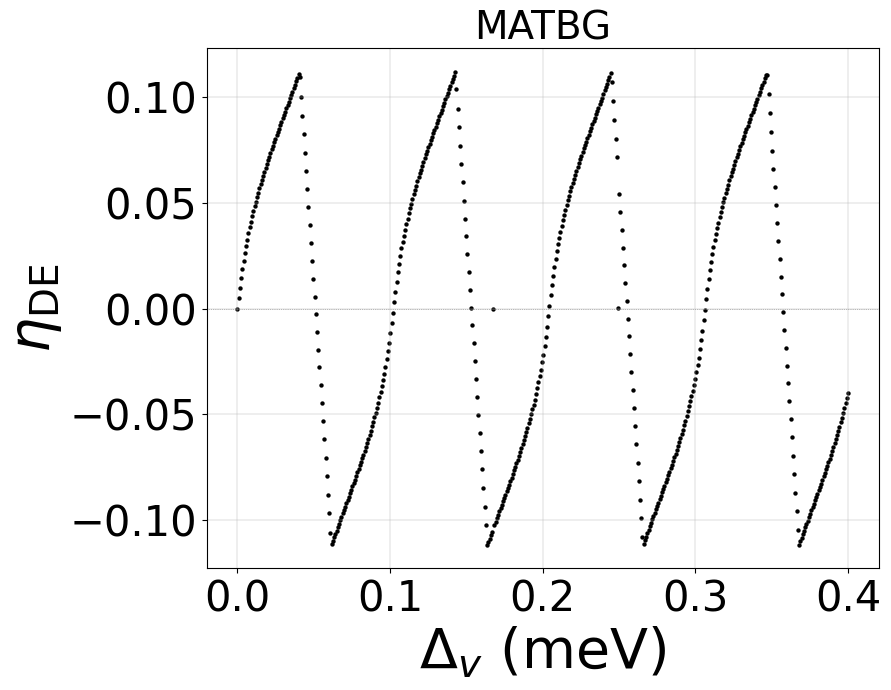

In [31]:
Ds     = 0.1                        # meV — superconducting gap
T      = 0.02                       # K   — temperature
N_beta = 1000
N_phi  = 1000
Dv_arr = np.linspace(0, 0.4, 500)  # meV — Δ_v sweep

# ------------------------------------------------------------------
# MATBG : η_DE vs Δ_v
# ------------------------------------------------------------------
Dv_arr, eta_matbg = compute_diode_efficiency_MATBG(Dv_arr, Ds=Ds, T=T, N_beta=N_beta, N_phi=N_phi)
plot_diode_efficiency(Dv_arr, eta_matbg, title_tag="MATBG")

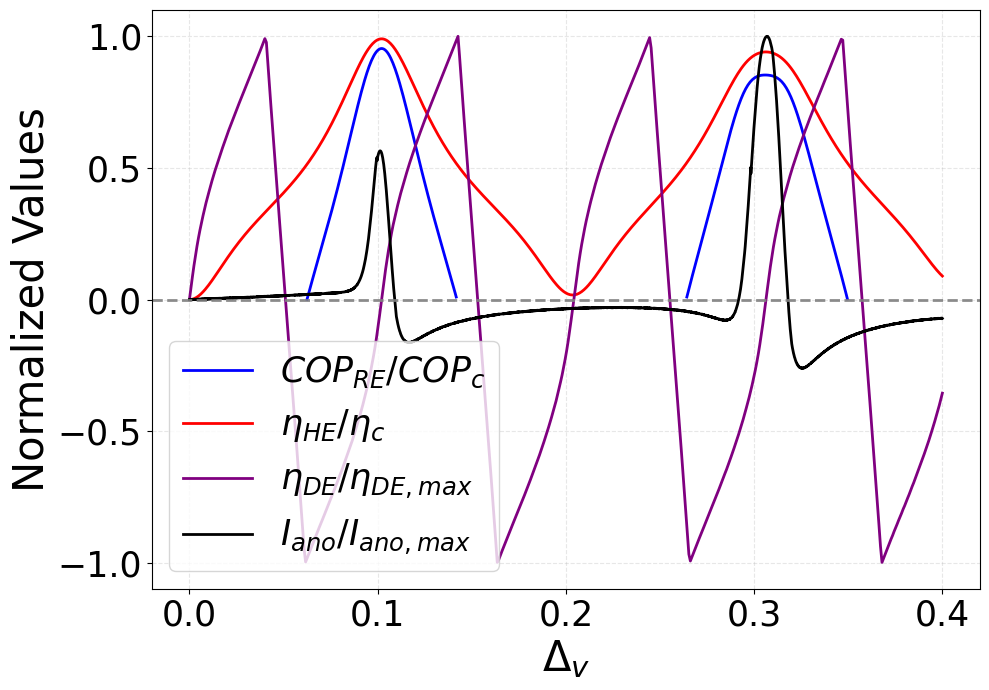

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Load data from files, skipping the first row (header)
# File 1: Dv_vs_cop_re.dat
data1 = np.loadtxt('Dv_vs_cop_re.dat', skiprows=1)
Dv1 = data1[:, 0]  # first column: Δ_v
cop_re = data1[:, 1]  # second column: COP_RE/COP_c

# File 2: Dv_vs_eta_he.dat
data2 = np.loadtxt('Dv_vs_eta_he.dat', skiprows=1)
Dv2 = data2[:, 0]  # first column: Δ_v
eta_he = data2[:, 1]  # second column: η_HE/η_c

# File 3: Dv_vs_etaDE.dat
data3 = np.loadtxt('Dv_vs_etaDE.dat', skiprows=1)
Dv3 = data3[:, 0]  # first column: Δ_v
eta_de = data3[:, 1]  # second column: η_DE/η_DE_max

# File 4: Dv_vs_Iano.dat
data4 = np.loadtxt('Dv_vs_Iano.dat', skiprows=1)
Dv4 = data4[:, 0]  # first column: Δ_v
I_ano = data4[:, 1]  # second column: I_ano/I_ano_max

# Create the plot
plt.figure(figsize=(10, 7))

# Plot each dataset with specified colors
plt.plot(Dv1, cop_re, 'b-', linewidth=2, label=r'$COP_{RE}/COP_c$')
plt.plot(Dv2, eta_he, 'r-', linewidth=2, label=r'$\eta_{HE}/\eta_c$')
plt.plot(Dv3, eta_de, 'purple', linewidth=2, label=r'$\eta_{DE}/\eta_{DE,max}$')
plt.plot(Dv4, I_ano, 'k-', linewidth=2, label=r'$I_{ano}/I_{ano,max}$')

# Customize the plot
plt.xlabel(r'$\Delta_v$', fontsize=30)
plt.ylabel('Normalized Values', fontsize=30)
plt.axhline(0, color='gray', lw=2, ls='--', alpha=0.9)
plt.tick_params(axis='both', labelsize=25)
plt.legend(loc='best', fontsize=25)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()